## Step 1: GPU Enable & Verify

Deep learning training involves a large number of matrix calculations, which run
much faster on a GPU than a CPU. Colab provides a free GPU, so first we enable it
and verify the connection before starting training.

**Runtime → Change runtime type → Hardware accelerator → T4 GPU → Save**

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU name: Tesla T4


## Step 2: Install Ultralytics (YOLOv8 library)

Instead of implementing YOLOv8 from scratch, we use the `ultralytics` library,
which provides a full implementation: loading the pretrained model, fine-tuning
it on custom data, and running inference — all through a few simple functions.

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 7.0 MB/s eta 0:00:00


## Step 3: Download the Dataset from Roboflow

We use the Roboflow Python package to download our pre-labeled "Closed_Opened"
eye dataset directly in YOLOv8 format. This downloads a zip file containing
images and their corresponding label files, then automatically extracts it
into the folder structure YOLOv8 requires for training.

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="pcxSebyDEsqP4vnlCm5x")
project = rf.workspace("rethinkai2").project("closed_opened")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.8 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Closed_Opened-1 in yolov8:: 100%|██████████| 1704/1704 [00:00<00:00, 6084.77it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


## Step 4: Verify Dataset Structure

Before training, let's check the dataset's `data.yaml` file — this confirms
the folder paths and class names YOLO will use during training.

In [ ]:
with open('/content/Closed_Opened-1/data.yaml', 'r') as f:
    print(f.read())

names:
- closed eye
- closed_eye
- open eye
- open_eye
nc: 4
roboflow:
  license: CC BY 4.0
  project: closed_opened
  url: https://universe.roboflow.com/rethinkai2/closed_opened/dataset/1
  version: 1
  workspace: rethinkai2
test: ../test/images
train: ../train/images
val: ../valid/images



## Step 5: Fix Duplicate Classes

The dataset labels "closed eye"/"closed_eye" and "open eye"/"open_eye" as
4 separate classes due to inconsistent naming, when there should only be 2
(closed_eye, open_eye). This script merges them and updates the label files
and data.yaml accordingly.

In [ ]:
import os

base_path = '/content/Closed_Opened-1'
class_map = {0: 0, 1: 0, 2: 1, 3: 1}  # merge duplicate names into 2 classes

for split in ['train', 'valid', 'test']:
    labels_dir = f'{base_path}/{split}/labels'
    if not os.path.exists(labels_dir):
        continue
    for filename in os.listdir(labels_dir):
        path = f'{labels_dir}/{filename}'
        lines = open(path).readlines()
        fixed_lines = [f"{class_map[int(l.split()[0])]} {' '.join(l.split()[1:])}\n" for l in lines if l.strip()]
        open(path, 'w').writelines(fixed_lines)

print("Classes merged: 4 -> 2")

Classes merged: 4 -> 2


## Step 6: Update data.yaml for 2 Classes

Since we merged the 4 duplicate class names into 2 distinct classes (`closed_eye` and `open_eye`) in the previous step, we must update the `data.yaml` configuration file so YOLOv8 knows the correct number of classes and names during training.

In [ ]:
yaml_content = """names:
- closed_eye
- open_eye
nc: 2
roboflow:
  license: CC BY 4.0
  project: closed_opened
  url: https://universe.roboflow.com/rethinkai2/closed_opened/dataset/1
  version: 1
  workspace: rethinkai2
test: ../test/images
train: ../train/images
val: ../valid/images
"""

with open('/content/Closed_Opened-1/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml successfully updated for 2 classes!")

data.yaml successfully updated for 2 classes!


## Step 6: Backup Downloaded Dataset to Google Drive

Since the dataset is already downloaded in Colab, we mount Google Drive and create a secure backup copy of the dataset folder there, ensuring it is never lost if the session disconnects.

In [ ]:
import shutil
from google.colab import drive

# 1. Mount Google Drive for backup
drive.mount('/content/drive')

# 2. Copy the existing downloaded dataset to Google Drive
source_path = '/content/Closed_Opened-1'
destination_path = '/content/drive/MyDrive/Closed_Opened-1'
shutil.copytree(source_path, destination_path, dirs_exist_ok=True)

print("Dataset successfully backed up to Google Drive!")

Mounted at /content/drive
Dataset successfully backed up to Google Drive!


## Step 7: Train YOLOv8 and Save Weights to Google Drive

We train the model using the fast local Colab dataset path, but we point the project output directly to Google Drive. This ensures your trained model weights (`best.pt`) are automatically saved to Drive so you never need to retrain the model again.

In [ ]:
from ultralytics import YOLO

# Initialize the pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# Train the model using the local dataset path,
# while saving the final trained weights permanently to Google Drive
results = model.train(
    data='/content/Closed_Opened-1/data.yaml',
    epochs=40,
    batch=16,
    imgsz=640,
    device='cuda',
    project='/content/drive/MyDrive/Colab Notebooks/DrowsinessDetection',
    name='eye_detection_model'
)

print("Training complete! The trained model is permanently saved in Google Drive.")

Ultralytics 8.4.143 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Closed_Opened-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=eye_detection_model-2, nbs=64, nms=None, 

## Step 9: Extract Training Metrics

We extract the performance metrics from our training results to check the model's accuracy on the training and validation sets.

In [ ]:
# Extract the metrics
precision = results.box.p.mean() * 100
recall = results.box.r.mean() * 100
map50 = results.box.map50 * 100
map50_95 = results.box.map * 100

# Print the metrics
print(f"Precision: {precision:.2f} %")
print(f"Recall: {recall:.2f} %")
print(f"mAP50: {map50:.2f} %")
print(f"mAP50-95: {map50_95:.2f} %")

Precision: 88.56 %
Recall: 74.43 %
mAP50: 81.89 %
mAP50-95: 44.23 %


## Step 10: Run Evaluation on Test Dataset

We load the best saved model weights from Google Drive and run validation specifically using the test dataset split.

In [ ]:
# Load the model and test it on the test dataset
model_path = '/content/drive/MyDrive/Colab Notebooks/DrowsinessDetection/eye_detection_model/weights/best.pt'
model = YOLO(model_path)
results = model.val(data='/content/Closed_Opened-1/data.yaml', split='test')

Ultralytics 8.4.143 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1288.6±482.4 MB/s, size: 29.7 KB)
val: Scanning /content/Closed_Opened-1/test/labels... 67 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 67/67 1.9Kit/s 0.0s
val: New cache created: /content/Closed_Opened-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.2it/s 2.3s
                   all         67        135      0.728      0.708      0.697      0.389
            closed_eye         63        123      0.921          1      0.966      0.543
              open_eye          8         12      0.536      0.417      0.428      0.236
Speed: 5.0ms preprocess, 5.6ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/runs/detect/val


## Step 11: Extract Test Dataset Metrics

Finally, we extract and display the performance metrics specifically computed from the test dataset evaluation.

In [ ]:
# Extract the metrics (for test dataset)
precision = results.box.p.mean() * 100
recall = results.box.r.mean() * 100
map50 = results.box.map50 * 100
map50_95 = results.box.map * 100

# Print the metrics
print(f"Precision: {precision:.2f} %")
print(f"Recall: {recall:.2f} %")
print(f"mAP50: {map50:.2f} %")
print(f"mAP50-95: {map50_95:.2f} %")

Precision: 72.85 %
Recall: 70.83 %
mAP50: 69.70 %
mAP50-95: 38.95 %


## Step 12: Visualize Predictions (Inference)

We pick a sample image from the test set and pass it through our trained model (`best.pt`) to visualize how well it detects and classifies open and closed eyes with bounding boxes.


image 1/1 /content/Closed_Opened-1/test/images/closed_eye_0809-jpg_face_2_jpg.rf.7ee111f5406c3ec008f53ceb91a6e409.jpg: 640x640 2 closed_eyes, 7.5ms
Speed: 0.9ms preprocess, 7.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


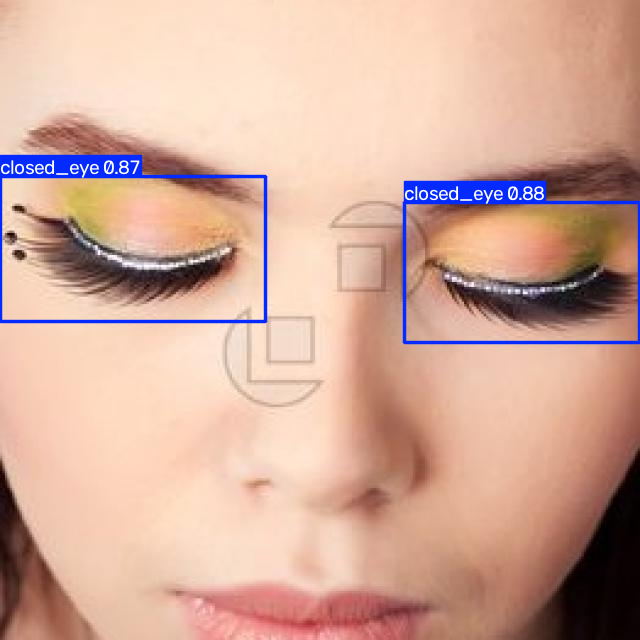

Inference completed successfully on the sample image!


In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import glob

# Load the trained model
model_path = '/content/drive/MyDrive/Colab Notebooks/DrowsinessDetection/eye_detection_model/weights/best.pt'
model = YOLO(model_path)

# Find sample images from the test set directory
test_images = glob.glob('/content/Closed_Opened-1/test/images/*.jpg')

if test_images:
    # Pick the first test image
    sample_image_path = test_images[0]

    # Run prediction/inference
    results = model(sample_image_path)

    # Plot the results (draw bounding boxes)
    annotated_image = results[0].plot()

    # Display the image inside Colab
    cv2_imshow(annotated_image)
    print("Inference completed successfully on the sample image!")
else:
    print("No test images found in the specified path.")